In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

loan_df = pd.read_csv("../Data/Loan_Default.csv")

loan_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148670 entries, 0 to 148669
Data columns (total 34 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   ID                         148670 non-null  int64  
 1   year                       148670 non-null  int64  
 2   loan_limit                 145326 non-null  object 
 3   Gender                     148670 non-null  object 
 4   approv_in_adv              147762 non-null  object 
 5   loan_type                  148670 non-null  object 
 6   loan_purpose               148536 non-null  object 
 7   Credit_Worthiness          148670 non-null  object 
 8   open_credit                148670 non-null  object 
 9   business_or_commercial     148670 non-null  object 
 10  loan_amount                148670 non-null  int64  
 11  rate_of_interest           112231 non-null  float64
 12  Interest_rate_spread       112031 non-null  float64
 13  Upfront_charges            10

In [2]:
loan_df["income"] = loan_df["income"].fillna(loan_df["income"].mean())
loan_df["loan_amount"] = loan_df["loan_amount"].fillna(loan_df["loan_amount"].mean())
loan_df["rate_of_interest"] = loan_df["rate_of_interest"].fillna(loan_df["rate_of_interest"].mean())
loan_df["approv_in_adv"] = loan_df["approv_in_adv"].fillna(loan_df["approv_in_adv"].mode())

prep_loan_df = loan_df.assign(
    total_units = loan_df["total_units"].map({
        "1U": "1U",
        "2U": "2U+",
        "3U": "2U+",
        "4U": "2U+"}),
    loan_amt_v_income = loan_df["loan_amount"]/loan_df["income"]
).drop([
    "year", 
     "ID", 
     "open_credit", 
    "construction_type", 
    "Security_Type",
    "Secured_by"], 
    axis=1
)

prep_loan_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148670 entries, 0 to 148669
Data columns (total 29 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   loan_limit                 145326 non-null  object 
 1   Gender                     148670 non-null  object 
 2   approv_in_adv              147762 non-null  object 
 3   loan_type                  148670 non-null  object 
 4   loan_purpose               148536 non-null  object 
 5   Credit_Worthiness          148670 non-null  object 
 6   business_or_commercial     148670 non-null  object 
 7   loan_amount                148670 non-null  int64  
 8   rate_of_interest           148670 non-null  float64
 9   Interest_rate_spread       112031 non-null  float64
 10  Upfront_charges            109028 non-null  float64
 11  term                       148629 non-null  float64
 12  Neg_ammortization          148549 non-null  object 
 13  interest_only              14

In [3]:
from sklearn.model_selection import train_test_split

features = [
    "loan_amount", 
    "income", 
    "Gender",
#     "rate_of_interest",
    "age",
    "lump_sum_payment",
    "credit_type",
    "total_units",
    "Credit_Worthiness",
    "Credit_Score",
    "approv_in_adv", 

]

X = pd.get_dummies(prep_loan_df[features], drop_first=True)
y = prep_loan_df["Status"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2, random_state=12345)

In [4]:
from sklearn.preprocessing import StandardScaler

std = StandardScaler()

X_train_std = std.fit_transform(X_train)
X_test_std = std.transform(X_test)

In [5]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=49, metric="manhattan")

knn.fit(X_train_std, y_train)

print(f"Train Accuracy: {knn.score(X_train_std, y_train)}")
print(f"Test Accuracy: {knn.score(X_test_std, y_test)}")

Train Accuracy: 0.8611690320844824
Test Accuracy: 0.8617743996771373


In [6]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(C=.6, penalty="l1", solver="saga", max_iter=1000) 

lr = logreg.fit(X_train_std, y_train)

print(f"Train Accuracy: {lr.score(X_train_std, y_train)}")
print(f"Test Accuracy: {lr.score(X_test_std, y_test)}")

Train Accuracy: 0.8607402300396853
Test Accuracy: 0.86211071500639


In [7]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(max_depth=10, min_samples_leaf=10)

dt.fit(X_train_std, y_train)

print(f"Train Accuracy: {round(dt.score(X_train_std, y_train), 3)}")
print(f"Test Accuracy: {round(dt.score(X_test_std, y_test), 3)}")

Train Accuracy: 0.869
Test Accuracy: 0.867


In [8]:
from sklearn.ensemble import VotingClassifier

model = VotingClassifier(estimators=[
    ('lr', lr), 
    ('dt', dt),
    ('knn', knn)], 
    voting='hard'
)

model.fit(X_train_std, y_train)
model.score(X_test_std,y_test)

0.8619761888746889

In [9]:
from sklearn.ensemble import VotingClassifier

model = VotingClassifier(estimators=[
    ('lr', lr), 
    ('dt', dt),
    ('knn', knn)], 
    voting='soft' 
)

model.fit(X_train_std, y_train)
model.score(X_test_std,y_test)

0.862615188000269

In [10]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=2023, max_depth=10) #max depth

rf.fit(X_train, y_train)

print(f"Training Accuracy: {rf.score(X_train, y_train)}")
print(f"Test Accuracy: {rf.score(X_test, y_test)}")

Training Accuracy: 0.867323602609807
Test Accuracy: 0.8657429205623193


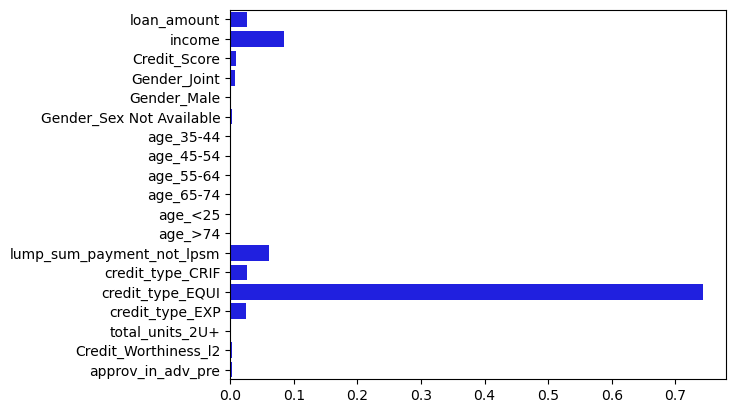

In [11]:
import seaborn as sns

sns.barplot(x=rf.feature_importances_, y=X.columns, color="blue");

In [12]:
from sklearn.model_selection import RandomizedSearchCV
      
rf = RandomForestClassifier(random_state=2023, n_jobs=-1)

params = {
    'n_estimators': np.arange(start=100, stop=1100, step=100),
    'max_features': [None, "sqrt"],
    'bootstrap': [True, False],
    'max_samples': [None, .3, .5, .9],
    'max_depth': np.arange(start=1, stop=11, step=1),
    'min_samples_leaf': [2, 5, 10, 20, 100],
}

grid = RandomizedSearchCV(
    rf, 
    params,
    n_iter=100,
    scoring="accuracy"
)

grid.fit(X_train, y_train)

grid.best_params_

c:\Users\User\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:425: FitFailedWarning: 
200 fits failed out of a total of 500.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
200 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\User\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 732, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\User\anaconda3\Lib\site-packages\sklearn\base.py", line 1151, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\User\anaconda3\Lib\site-packages\sklearn\ensemble\_forest.py", line 402, in fit
    raise ValueError(


{'n_estimators': 1000,
 'min_samples_leaf': 2,
 'max_samples': 0.9,
 'max_features': None,
 'max_depth': 10,
 'bootstrap': True}

optimizuota versija \I/

In [ ]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

rf = RandomForestClassifier(random_state=2023, n_jobs=-1)

params = {
    'n_estimators': [100, 200, 300, 500, 700],
    'max_features': [None, "sqrt"],
    'bootstrap': [True, False],
    'max_depth': [None, 3, 5, 7, 10],
    'min_samples_leaf': [1, 2, 5, 10]
}

grid = RandomizedSearchCV(
    rf,
    param_distributions=params,
    n_iter=30,
    cv=3,
    scoring="accuracy",
    random_state=2023,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print(grid.best_params_)

In [13]:
from sklearn.model_selection import GridSearchCV
import numpy as np


rf = RandomForestClassifier(random_state=2023, n_jobs=-1)


params = {
    'n_estimators': np.arange(start=150, stop=250, step=10),
    'bootstrap': [True],
    'max_features': [None, "sqrt"],
    'max_samples': [.8, .9, .95],
    'max_depth': [9],
    'min_samples_leaf': [2, 3, 4]    
}

grid = GridSearchCV(
    rf, 
    params,
    scoring="accuracy"
)

grid.fit(X_train, y_train)

grid.best_params_

{'bootstrap': True,
 'max_depth': 9,
 'max_features': None,
 'max_samples': 0.8,
 'min_samples_leaf': 2,
 'n_estimators': 160}

In [14]:
rf = RandomForestClassifier(random_state=2023, n_jobs=-1, **grid.best_params_)

rf.fit(X_train, y_train)

print(f"Training Accuracy: {rf.score(X_train, y_train)}")
print(f"Test Accuracy: {rf.score(X_test, y_test)}")

Training Accuracy: 0.8697030335642698
Test Accuracy: 0.8680634963341629


In [15]:
from sklearn.ensemble import GradientBoostingClassifier

gbm = GradientBoostingClassifier(random_state=2023)

gbm.fit(X_train, y_train)

print(f"Training Accuracy: {gbm.score(X_train, y_train)}")
print(f"Test Accuracy: {gbm.score(X_test, y_test)}")

Training Accuracy: 0.8665921167686823
Test Accuracy: 0.8667518665500773


geriausias rezultatas be jokių hiperparametrų

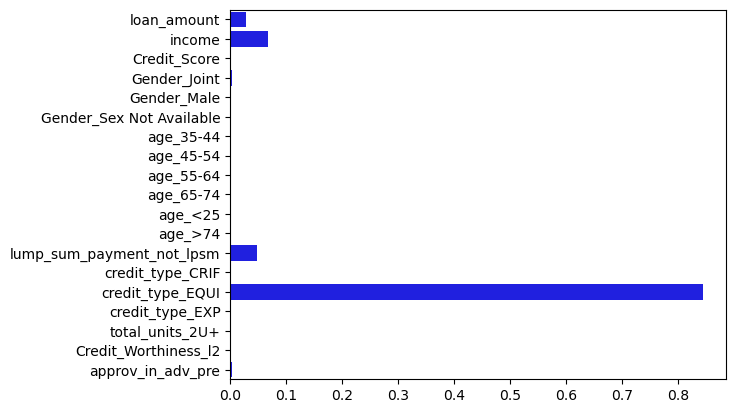

In [16]:
import seaborn as sns

sns.barplot(x=gbm.feature_importances_, y=X.columns, color="blue");

In [17]:
import numpy as np

from sklearn.model_selection import RandomizedSearchCV
      
gb = GradientBoostingClassifier(random_state=2023)

params = {
    'n_estimators': [20, 40, 60, 80, 100, 200],
    'learning_rate': [.01, .1],
    'max_features': ["sqrt"],
    'subsample': [.8, .9, .95],
    'max_depth': np.arange(start=3, stop=12, step=2),
    'min_samples_leaf': [2, 5, 10]    
}

grid = RandomizedSearchCV(
    gb, 
    params,
    n_iter=100,
    scoring="accuracy"
)

grid.fit(X_train, y_train)

grid.best_params_

{'subsample': 0.8,
 'n_estimators': 80,
 'min_samples_leaf': 10,
 'max_features': 'sqrt',
 'max_depth': 9,
 'learning_rate': 0.1}

In [18]:
grid.score(X_train, y_train)

0.8732259366381919

In [19]:
grid.score(X_test, y_test)

0.8669872872805543

In [20]:
import numpy as np

from sklearn.model_selection import GridSearchCV
      
gb = GradientBoostingClassifier(random_state=2023)

params = {
    'n_estimators': [50, 60, 70],
    'learning_rate': [.1],
    'max_features': ["sqrt"],
    'subsample': [.8],
    'max_depth': [9],
    'min_samples_leaf': [10]    
}

grid = GridSearchCV(
    gb, 
    params,
    scoring="accuracy"
)

grid.fit(X_train, y_train)

grid.best_params_

{'learning_rate': 0.1,
 'max_depth': 9,
 'max_features': 'sqrt',
 'min_samples_leaf': 10,
 'n_estimators': 60,
 'subsample': 0.8}

In [21]:
from sklearn.ensemble import GradientBoostingClassifier

gbm = GradientBoostingClassifier(random_state=2023, **grid.best_params_)

gbm.fit(X_train, y_train)

print(f"Training Accuracy: {gbm.score(X_train, y_train)}")
print(f"Test Accuracy: {gbm.score(X_test, y_test)}")

Training Accuracy: 0.8715611757583911
Test Accuracy: 0.8664491827537499


In [22]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, gbm.predict(X_test))

array([[22138,   207],
       [ 3764,  3625]], dtype=int64)

<Axes: xlabel='Importance', ylabel='Feature'>

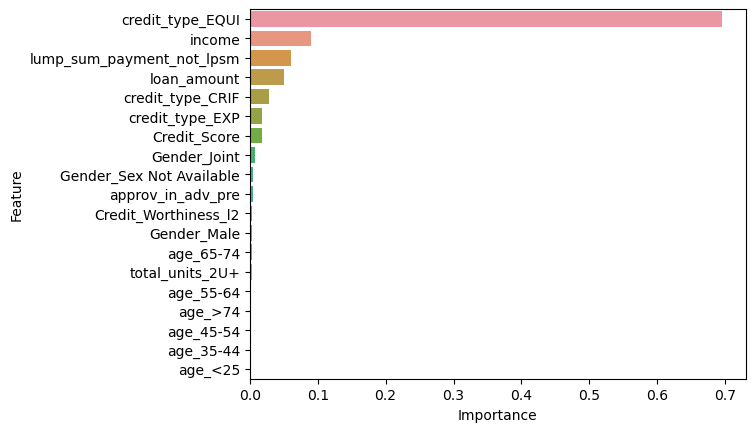

In [23]:
importance_df = (
    pd.DataFrame({"Feature": X_train.columns, "Importance": gbm.feature_importances_})
    .sort_values("Importance", ascending=False)
)

sns.barplot(importance_df, x="Importance", y="Feature" )

In [ ]:
#!conda install shap --y

Retrieving notices: ...working... done
Solving environment: ...working... unsuccessful initial attempt using frozen solve. Retrying with flexible solve.
Solving environment: ...working... unsuccessful attempt using repodata from current_repodata.json, retrying with next repodata source.
Solving environment: ...working... done

## Package Plan ##

  environment location: C:\Users\User\anaconda3

  added / updated specs:
    - shap


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    pyparsing-3.2.5            |  py311haa95532_0         558 KB
    shap-0.48.0                |  py311hdce4354_0         3.1 MB
    slicer-0.0.8               |  py311h6b59318_1          48 KB
    ------------------------------------------------------------
                                           Total:         3.7 MB

The following NEW packages will be INSTALLED:

  pyparsing          pkgs/main/win-64::pyparsin

DEBUG:urllib3.connectionpool:Starting new HTTPS connection (1): repo.anaconda.com:443
DEBUG:urllib3.connectionpool:Starting new HTTPS connection (1): repo.anaconda.com:443
DEBUG:urllib3.connectionpool:Starting new HTTPS connection (1): repo.anaconda.com:443
DEBUG:urllib3.connectionpool:https://repo.anaconda.com:443 "GET /pkgs/r/notices.json HTTP/1.1" 404 None
DEBUG:urllib3.connectionpool:https://repo.anaconda.com:443 "GET /pkgs/msys2/notices.json HTTP/1.1" 404 None
DEBUG:urllib3.connectionpool:https://repo.anaconda.com:443 "GET /pkgs/main/notices.json HTTP/1.1" 404 None
DEBUG:urllib3.connectionpool:Starting new HTTPS connection (1): repo.anaconda.com:443
DEBUG:urllib3.connectionpool:Starting new HTTPS connection (1): repo.anaconda.com:443
DEBUG:urllib3.connectionpool:Starting new HTTPS connection (1): repo.anaconda.com:443
DEBUG:urllib3.connectionpool:Starting new HTTPS connection (1): repo.anaconda.com:443
DEBUG:urllib3.connectionpool:Starting new HTTPS connection (1): repo.anaconda.c

In [25]:
for col in X_test.select_dtypes("bool"):
    X_test[col] = X_test[col].astype("int")

X_test

,loan_amount,income,Credit_Score,Gender_Joint,Gender_Male,Gender_Sex Not Available,age_35-44,age_45-54,age_55-64,age_65-74,age_<25,age_>74,lump_sum_payment_not_lpsm,credit_type_CRIF,credit_type_EQUI,credit_type_EXP,total_units_2U+,Credit_Worthiness_l2,approv_in_adv_pre
111796,1296500,6957.338876,862,1,0,0,0,1,0,0,0,0,1,1,0,0,0,0,0
109914,276500,7560.000000,512,0,1,0,1,0,0,0,0,0,1,0,0,0,0,0,0
32797,316500,10620.000000,721,0,1,0,0,0,0,0,0,1,1,0,0,0,0,0,0
82514,206500,2040.000000,506,1,0,0,0,0,1,0,0,0,1,0,0,1,0,1,0
84181,256500,4200.000000,861,0,0,1,0,0,0,0,0,0,1,0,0,1,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67652,406500,5700.000000,558,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0
115283,176500,3600.000000,558,1,0,0,0,0,1,0,0,0,1,1,0,0,0,0,0
67250,206500,7680.000000,715,0,0,1,0,0,1,0,0,0,1,1,0,0,0,0,0
66582,406500,14100.000000,748,0,1,0,0,1,0,0,0,0,1,0,0,0,0,0,0


In [26]:
import shap

explainer = shap.Explainer(gbm)

shap_values = explainer.shap_values(X_test.sample(50, random_state=12345))

In [27]:
shap_values

array([[-3.54505358e-02, -9.77010256e-02,  1.23212141e-02,
         7.41547123e-02, -3.20881805e-02, -5.54424726e-02,
         9.58044839e-03, -1.08840148e-02,  8.28622922e-02,
         2.62983849e-03, -3.78717896e-04, -2.76284259e-03,
        -5.38097862e-02,  4.56627144e-02, -7.82983702e-01,
         4.83811371e-02, -5.32252734e-03, -1.98928713e-02,
         2.89421625e-02],
       [ 1.35853398e-01, -4.29520505e-01,  2.27538242e-02,
         1.11266143e-01, -3.97984122e-02, -6.27982457e-02,
         2.30511766e-02, -6.46264077e-03,  1.08129043e-01,
        -4.57729095e-03, -9.40293139e-04, -4.35729502e-03,
        -5.09431817e-02, -7.68048097e-02, -6.66876664e-01,
         1.52343835e-02, -6.75549153e-03, -1.76539404e-02,
         3.33403871e-02],
       [-5.60375669e-02, -1.27266300e-01, -2.87912082e-02,
         5.94258664e-02, -1.57972846e-02, -5.17106686e-02,
        -1.10927200e-02, -1.66967993e-02, -2.91849171e-02,
         4.91521633e-03, -7.80605229e-04, -5.94021777e-03,
    

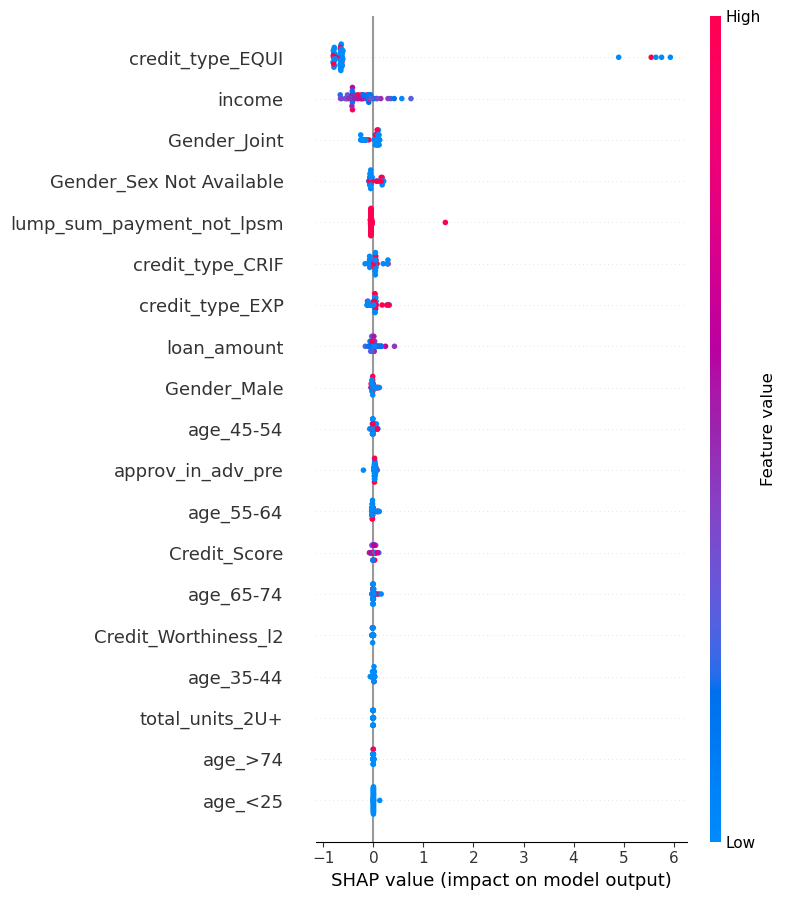

In [ ]:
import shap

X_plot = X_test.iloc[:shap_values.shape[0], :]   # equal line count
shap.summary_plot(shap_values, X_plot, feature_names=X_plot.columns)

#shap.plots.beeswarm(shap_values)


In [31]:
X_test.sample(50, random_state=12345).iloc[1]

loan_amount                  526500.0
income                         9000.0
Credit_Score                    562.0
Gender_Joint                      0.0
Gender_Male                       0.0
Gender_Sex Not Available          0.0
age_35-44                         0.0
age_45-54                         0.0
age_55-64                         1.0
age_65-74                         0.0
age_<25                           0.0
age_>74                           0.0
lump_sum_payment_not_lpsm         1.0
credit_type_CRIF                  1.0
credit_type_EQUI                  0.0
credit_type_EXP                   0.0
total_units_2U+                   0.0
Credit_Worthiness_l2              0.0
approv_in_adv_pre                 0.0
Name: 51742, dtype: float64

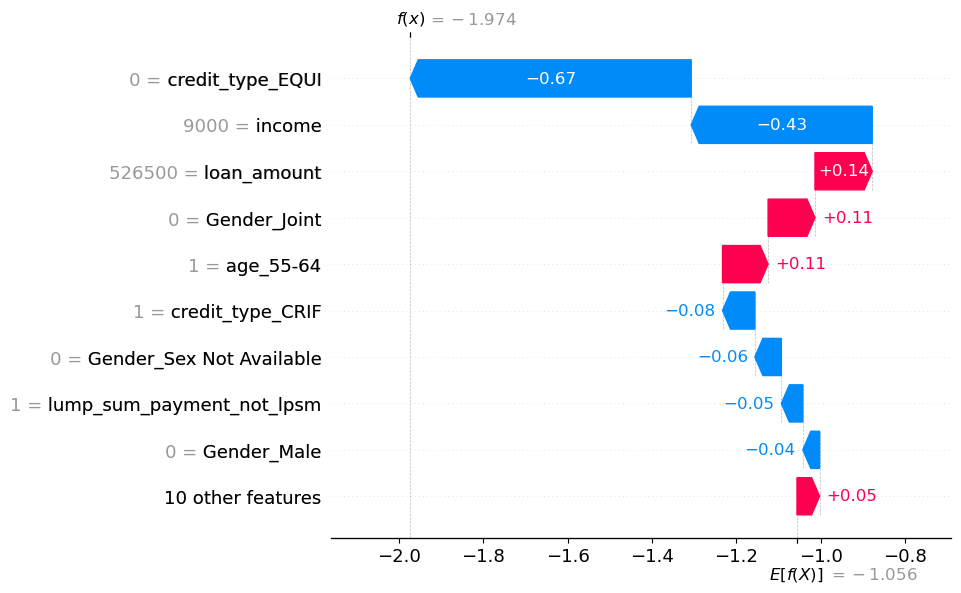

In [39]:
shap.plots.waterfall(shap.Explainer(gbm)(X_test.sample(50, random_state=12345))[1])



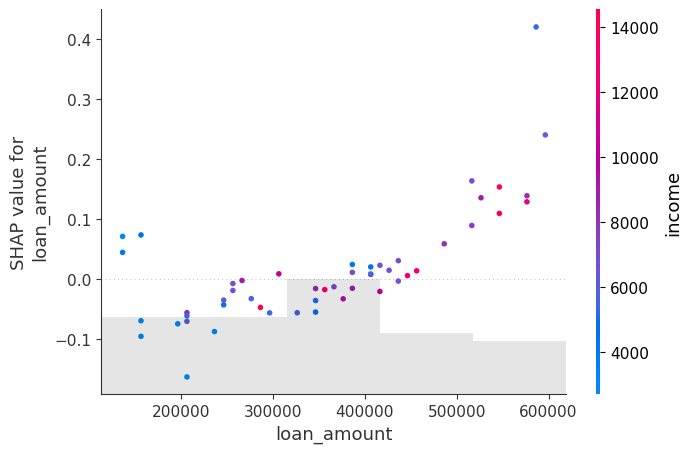

In [41]:
shap.plots.scatter(shap.Explainer(gbm)(X_test.sample(50, random_state=12345))[:, 0], color=shap.Explainer(gbm)(X_test.sample(50, random_state=12345))[:, 1])
